In [1]:
import pandas as pd

In [2]:
import numpy as np

df_matches = pd.read_csv('../../data/preprocessed/imputed_data.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)
season_labels, _ = pd.factorize(df_matches['result_match'])
feature_cols = [col for col in df_matches.columns if col not in
                ["match_api_id", "result_match", "stage", "season" ,"date", "home_team", "away_team"]]

df_matches = df_matches[feature_cols]
df_matches = df_matches.filter(like="home")
df_matches

,points_home,home_team_last_goal,home_team_last_shoton,home_team_last_possession,avg_team_strength_home,avg_team_aggression_home,avg_team_acceleration_home,goal_conversion_rate_home,home_team_strength_x_acceleration,rolling_avg_goals_home,...,form_home_gamma_0.25alpha0.8,form_home_gamma_0.25alpha1.0,form_home_gamma_0.33alpha0.6,form_home_gamma_0.33alpha0.8,form_home_gamma_0.33alpha1.0,form_home_gamma_0.5alpha0.6,form_home_gamma_0.5alpha0.8,form_home_gamma_0.5alpha1.0,momentum_home,streak_home
0,4.0,1.0,5.0,47.0,63.318182,62.500000,74.590909,0.200000,4722.960744,1.000000,...,0.157289,0.196611,0.082552,0.110070,0.137587,0.029975,0.039967,0.049958,2.2,-4.0
1,3.0,3.0,5.0,53.0,71.318182,73.590909,70.136364,0.600000,5001.997934,3.000000,...,0.091131,0.113914,0.060963,0.081284,0.101605,0.037541,0.050055,0.062569,2.2,-3.0
2,3.0,1.0,7.0,47.0,63.924242,45.484848,82.136364,0.142857,5250.504821,1.000000,...,0.159882,0.199853,0.102036,0.136047,0.170059,0.056343,0.075124,0.093904,2.9,-3.0
3,3.0,1.0,12.0,34.0,78.318182,70.833333,80.939394,0.083333,6339.026171,1.000000,...,0.203162,0.253953,0.152100,0.202799,0.253499,0.152824,0.203766,0.254707,1.0,-1.0
4,6.0,1.0,6.0,35.0,80.189394,77.742424,83.666667,0.166667,6709.179293,1.000000,...,0.101989,0.127486,0.055045,0.073393,0.091742,0.021259,0.028345,0.035431,1.8,-4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,48.0,1.0,4.0,47.0,73.727273,70.900000,53.936364,0.250000,3976.580992,1.246612,...,0.167297,0.209121,0.085157,0.113542,0.141928,0.030123,0.040164,0.050205,2.9,-4.0
2971,60.0,2.0,4.0,57.0,79.300000,71.627273,70.818182,0.500000,5615.881818,2.702803,...,0.607040,0.758800,0.487197,0.649595,0.811994,0.542676,0.723568,0.904460,3.0,3.0
2972,44.0,1.0,4.0,44.0,72.327273,70.127273,73.800000,0.250000,5337.752727,1.416257,...,0.267362,0.334203,0.229500,0.306000,0.382500,0.309605,0.412807,0.516008,2.5,1.0
2973,68.0,2.0,7.0,31.0,70.627273,78.036364,73.400000,0.285714,5184.041818,1.898222,...,0.550039,0.687549,0.438932,0.585242,0.731553,0.499138,0.665517,0.831896,3.2,2.0


<Figure size 1500x1500 with 0 Axes>

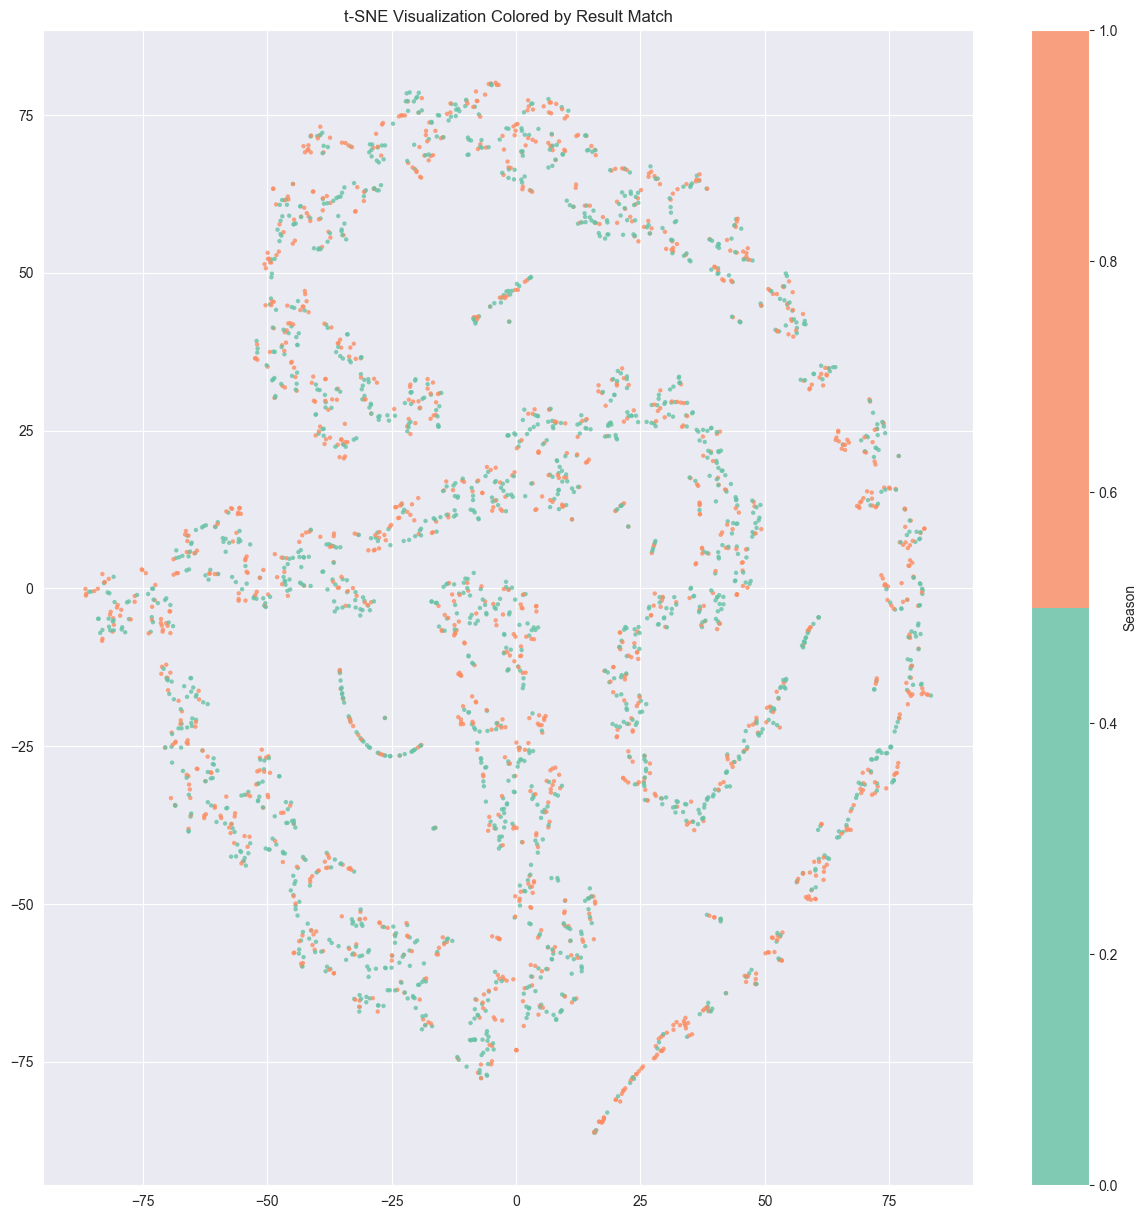

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

tsne = TSNE(n_components=2, perplexity=10., init="random", learning_rate="auto", random_state=42)
X = df_matches.fillna(df_matches.mean())
projection_2D = tsne.fit_transform(X)

palette = sns.color_palette("Set2", n_colors=len(set(season_labels)))
cmap = ListedColormap(palette)
plt.figure(figsize=(15, 15))
plt.figure(figsize=(15, 15))
plt.scatter(projection_2D[:, 0], projection_2D[:, 1], c=season_labels, cmap=cmap, edgecolor='none', alpha=0.80, s=10)
plt.colorbar(label="Season")
plt.title("t-SNE Visualization Colored by Result Match")
plt.show()
plt.show()